In [7]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [8]:
df = pd.read_csv("GEFCom2014_prepared.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hour"]).reset_index(drop=True)

df["hour"] = df["hour"].astype(int) - 1
df["day_of_week"] = df["day_of_week"].astype(int)
df["month"] = df["month"].astype(int) - 1
df["is_weekend"] = df["is_weekend"].astype(int)

if "sum_zones" in df.columns:
    df = df.drop(columns=["sum_zones"])

In [9]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']

zone_cols = ["zone_residential", "zone_commercial", "zone_industrial"]

In [10]:
SEQ_LEN = 24

class JointDataset(Dataset):
    def __init__(self, df):
        self.Xl = df[load_features].values.astype(np.float32)
        self.Xt = df[temp_features].values.astype(np.float32)
        self.Xc = df[calendar_features].values.astype(np.int64)
        self.y = df[zone_cols].values.astype(np.float32)

    def __len__(self):
        return len(self.Xl) - SEQ_LEN

    def __getitem__(self, idx):
        return (
            torch.tensor(self.Xl[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xt[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xc[idx:idx+SEQ_LEN]),
            torch.tensor(self.y[idx+SEQ_LEN])
        )

dataset = JointDataset(df)

train_size = int(0.8 * len(dataset))
train_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, len(dataset) - train_size]
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [11]:
class JointModel(nn.Module):
    def __init__(self, num_zones):
        super().__init__()

        self.lstm = nn.LSTM(len(load_features), 64, batch_first=True)

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        self.fc = nn.Sequential(
            nn.Linear(64 + 32 + 18, 64),
            nn.ReLU(),
            nn.Linear(64, num_zones)
        )

    def forward(self, Xl, Xt, Xc):
        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        hour = self.hour_emb(Xc[:, -1, 0])
        day = self.day_emb(Xc[:, -1, 1])
        month = self.month_emb(Xc[:, -1, 2])
        weekend = self.weekend_emb(Xc[:, -1, 3])

        cal = torch.cat([hour, day, month, weekend], dim=1)

        return self.fc(torch.cat([load_out, temp_out, cal], dim=1))

In [12]:
joint_model = JointModel(len(zone_cols)).to(device)
optimizer = torch.optim.Adam(joint_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

EPOCHS = 20

for epoch in range(EPOCHS):
    joint_model.train()
    total_loss = 0

    for Xl, Xt, Xc, y in train_loader:
        Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

        optimizer.zero_grad()
        preds = joint_model(Xl, Xt, Xc)

        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Joint Epoch {epoch+1} | Loss: {total_loss:.4f}")

Joint Epoch 1 | Loss: 108430676.0039
Joint Epoch 2 | Loss: 27472445.8730
Joint Epoch 3 | Loss: 20106894.8506
Joint Epoch 4 | Loss: 12441363.1401
Joint Epoch 5 | Loss: 7779546.5920
Joint Epoch 6 | Loss: 5004866.9241
Joint Epoch 7 | Loss: 4168711.5356
Joint Epoch 8 | Loss: 3847937.3540
Joint Epoch 9 | Loss: 3613733.2157
Joint Epoch 10 | Loss: 3444028.7043
Joint Epoch 11 | Loss: 3332040.3469
Joint Epoch 12 | Loss: 3244485.2179
Joint Epoch 13 | Loss: 3236867.7666
Joint Epoch 14 | Loss: 3178800.0939
Joint Epoch 15 | Loss: 3156697.6821
Joint Epoch 16 | Loss: 3134231.0039
Joint Epoch 17 | Loss: 3100511.0421
Joint Epoch 18 | Loss: 3074180.3640
Joint Epoch 19 | Loss: 3058972.4407
Joint Epoch 20 | Loss: 3047523.0519


In [13]:
ind_models = []
for i in range(len(zone_cols)):
    model = JointModel(1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for Xl, Xt, Xc, y in train_loader:
            Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)
            target = y[:, i].unsqueeze(1).to(device)

            optimizer.zero_grad()
            preds = model(Xl, Xt, Xc)

            loss = criterion(preds, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

    ind_models.append(model)

In [14]:
# Joint predictions
joint_model.eval()
joint_preds, y_true = [], []

with torch.no_grad():
    for Xl, Xt, Xc, y in test_loader:
        Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

        preds = joint_model(Xl, Xt, Xc).cpu().numpy()

        joint_preds.append(preds)
        y_true.append(y.numpy())

joint_preds = np.vstack(joint_preds)
y_true = np.vstack(y_true)

# Independent predictions
ind_preds = []

for i, model in enumerate(ind_models):
    model.eval()
    preds_list = []

    with torch.no_grad():
        for Xl, Xt, Xc, y in test_loader:
            Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

            preds = model(Xl, Xt, Xc).cpu().numpy()
            preds_list.append(preds)

    ind_preds.append(np.vstack(preds_list))

ind_preds = np.hstack(ind_preds)

In [15]:
joint_mae = []
ind_mae = []

for i in range(len(zone_cols)):
    joint_mae.append(mean_absolute_error(y_true[:, i], joint_preds[:, i]))
    ind_mae.append(mean_absolute_error(y_true[:, i], ind_preds[:, i]))

results = pd.DataFrame({
    "Zone": zone_cols,
    "Joint_MAE": joint_mae,
    "Independent_MAE": ind_mae,
    "Improvement": np.array(ind_mae) - np.array(joint_mae)
})

results.to_csv("outputs/tables/rq5_results.csv", index=False)
results

,Zone,Joint_MAE,Independent_MAE,Improvement
0,zone_residential,46.950554,53.955421,7.004868
1,zone_commercial,42.235359,45.107090,2.871731
2,zone_industrial,39.147560,41.396416,2.248856


In [16]:
actual_corr = np.corrcoef(y_true.T)
pred_corr = np.corrcoef(joint_preds.T)

print("Actual Correlation:\n", actual_corr)
print("Predicted Correlation:\n", pred_corr)

Actual Correlation:
 [[1.         0.26223451 0.7857677 ]
 [0.26223451 1.         0.71620483]
 [0.7857677  0.71620483 1.        ]]
Predicted Correlation:
 [[1.         0.23055741 0.8194494 ]
 [0.23055741 1.         0.74662306]
 [0.8194494  0.74662306 1.        ]]


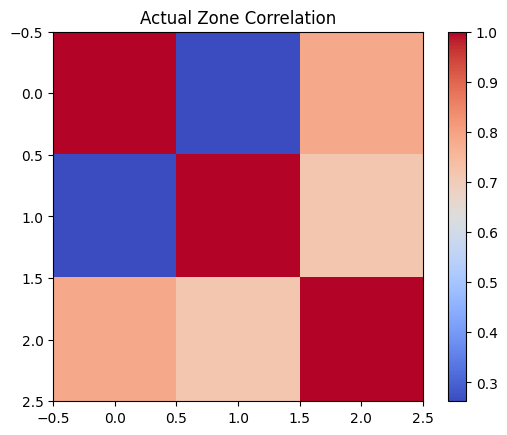

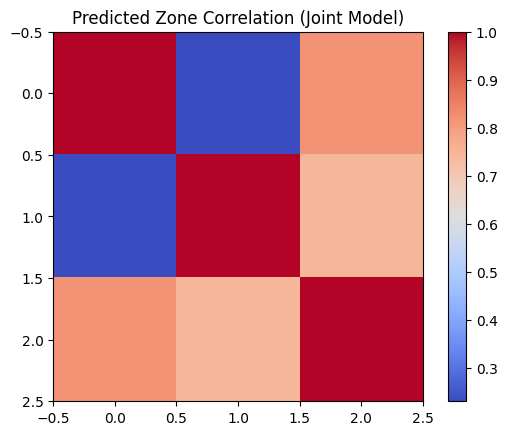

In [17]:
plt.imshow(actual_corr, cmap="coolwarm")
plt.title("Actual Zone Correlation")
plt.colorbar()
plt.savefig("outputs/figures/rq5_actual_corr.pdf")
plt.show()

plt.imshow(pred_corr, cmap="coolwarm")
plt.title("Predicted Zone Correlation (Joint Model)")
plt.colorbar()
plt.savefig("outputs/figures/rq5_pred_corr.pdf")
plt.show()

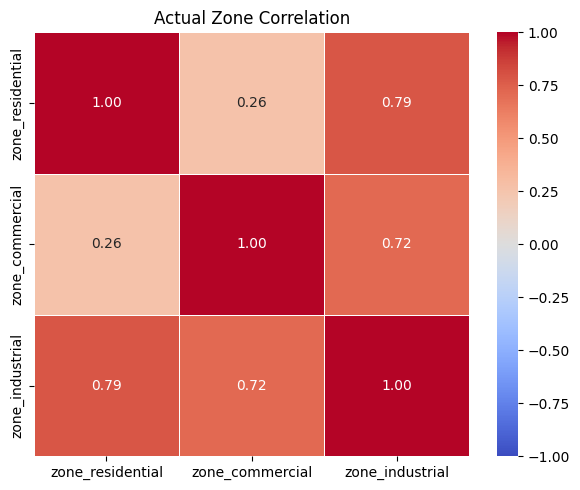

In [20]:
import seaborn as sns

zone_labels = ["zone_residential", "zone_commercial", "zone_industrial"]

plt.figure(figsize=(6,5))

sns.heatmap(
    actual_corr,
    annot=True,              # show values
    fmt=".2f",               # 2 decimal places
    cmap="coolwarm",
    xticklabels=zone_labels,
    yticklabels=zone_labels,
    vmin=-1, vmax=1,         # proper correlation scale
    linewidths=0.5
)

plt.title("Actual Zone Correlation")
plt.tight_layout()
plt.savefig("outputs/figures/rq5_actual_corr_improved.pdf")
plt.show()

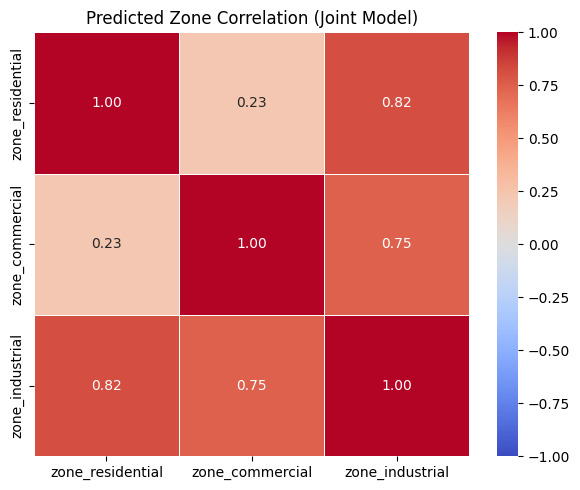

In [21]:
plt.figure(figsize=(6,5))

sns.heatmap(
    pred_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    xticklabels=zone_labels,
    yticklabels=zone_labels,
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title("Predicted Zone Correlation (Joint Model)")
plt.tight_layout()
plt.savefig("outputs/figures/rq5_pred_corr_improved.pdf")
plt.show()